# 06. Learning & Education Paths

This notebook details how developers learn, their academic background, and the impact of AI tools on education. We analyze:
1. Developer coding education methods
2. AI tools adoption in learning to code (2023-2025)
3. Educational levels of professional developers

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visuals
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

# Resolve path to sql_connector relative to this notebook
current_dir = os.path.abspath('')
project_root = os.path.dirname(current_dir)
silver_utils_dir = os.path.join(project_root, 'Data Warehouse', 'Silver Layer', 'utils')
sys.path.append(silver_utils_dir)

# Ensure the images output directory exists
images_dir = os.path.join(current_dir, 'images')
os.makedirs(images_dir, exist_ok=True)

from sql_connector import SQLConnector

db = SQLConnector("Stack_Overflow_Survey")
db.connect()

Successfully Connected to Stack_Overflow_Survey


### 1. How Developers Learn to Code

Let's see what primary learning methods developers rely on.

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


C:\Users\Ayush\AppData\Local\Temp\ipykernel_19416\1573939980.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_learn_2025, x='Count', y='LearnMethod', palette='viridis')


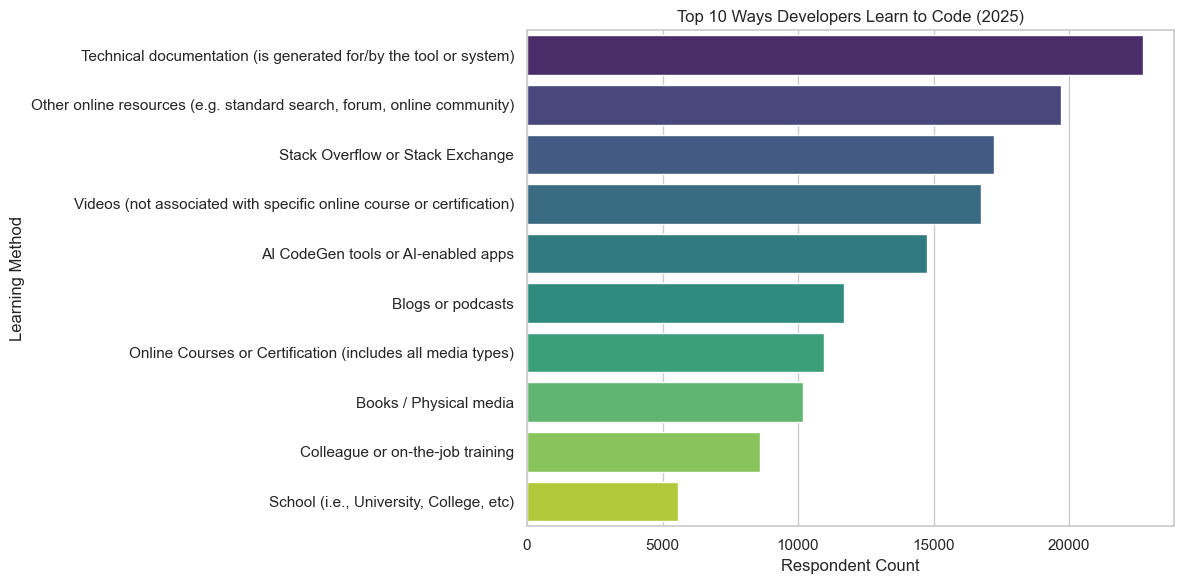

In [2]:
learn_query = """
SELECT 
    YEAR(f.SurveyYear) AS Year,
    learn.LearnCode_Clean AS LearnMethod,
    COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Bridge_LearnCode_Clean learn ON f.ResponseKey = learn.ResponseKey
WHERE learn.LearnCode_Clean IS NOT NULL AND learn.LearnCode_Clean <> 'Unknown' AND learn.LearnCode_Clean <> ''
GROUP BY YEAR(f.SurveyYear), learn.LearnCode_Clean;
"""
df_learn = db.read_query(learn_query)

if df_learn is not None and not df_learn.empty:
    df_learn_2025 = df_learn[df_learn['Year'] == 2025].sort_values(by='Count', ascending=False).head(10)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_learn_2025, x='Count', y='LearnMethod', palette='viridis')
    plt.title('Top 10 Ways Developers Learn to Code (2025)')
    plt.xlabel('Respondent Count')
    plt.ylabel('Learning Method')
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '06_learning_methods.png'), dpi=300)
    plt.show()
else:
    print("No learning methods data available.")

### 2. The Rise of AI Tools in Developer Education (2023-2025)

Are developers using AI tool outputs to learn coding concepts?

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


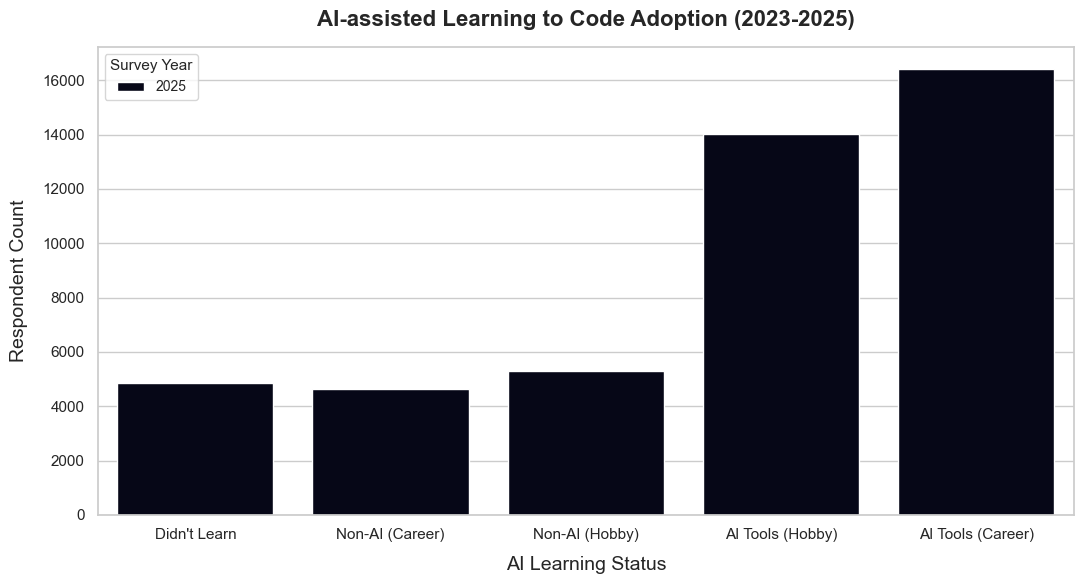

In [2]:
learn_ai_query = """
SELECT 
    YEAR(f.SurveyYear) AS Year,
    edu.LearnCodeAI,
    COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Dim_Education edu ON f.Dim_EducationID = edu.Dim_EducationID
WHERE edu.LearnCodeAI IS NOT NULL AND edu.LearnCodeAI <> 'Unknown' AND edu.LearnCodeAI <> ''
GROUP BY YEAR(f.SurveyYear), edu.LearnCodeAI;
"""
df_learn_ai = db.read_query(learn_ai_query)

if df_learn_ai is not None and not df_learn_ai.empty:
    df_chart = df_learn_ai.copy()
    
    label_mapping = {
        "No, I didn't spend time learning in the past year": "Didn't Learn",
        "No, I learned something that was not related to AI or AI enablement as required for my job or to benefit my career": "Non-AI (Career)",
        "No, I learned something that was not related to AI or AI enablement for my personal curiosity and/or hobbies": "Non-AI (Hobby)",
        "Yes, I learned how to use AI-enabled tools for my personal curiosity and/or hobbies": "AI Tools (Hobby)",
        "Yes, I learned how to use AI-enabled tools required for my job or to benefit my career": "AI Tools (Career)"
    }
    df_chart['AI_Learning_Clean'] = df_chart['LearnCodeAI'].map(label_mapping).fillna(df_chart['LearnCodeAI'])
    
    plt.figure(figsize=(11, 6))
    ax = sns.barplot(data=df_chart, x='AI_Learning_Clean', y='Count', hue='Year', palette='rocket')
    
    plt.title('AI-assisted Learning to Code Adoption (2023-2025)', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('AI Learning Status', fontsize=14, labelpad=10)
    plt.ylabel('Respondent Count', fontsize=14, labelpad=10)
    
    plt.xticks(rotation=0, fontsize=11)
    plt.yticks(fontsize=11)
    
    plt.legend(title='Survey Year', title_fontsize=11, fontsize=10)
    
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '06_ai_in_education.png'), dpi=300)
    plt.show()
else:
    print("No AI in learning data available.")

### 3. Professional Developers Educational Level

What is the educational profile of professional developers in 2025?

c:\Users\Ayush\Git Repo\Stack-Over-Flow-Survey-Data-Engineering-Project\Data Warehouse\Silver Layer\utils\sql_connector.py:46: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, self.conn)


Query executed successfully


C:\Users\Ayush\AppData\Local\Temp\ipykernel_19416\4002956435.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_edu_sorted, x='Count', y='Education_Level', palette='mako')


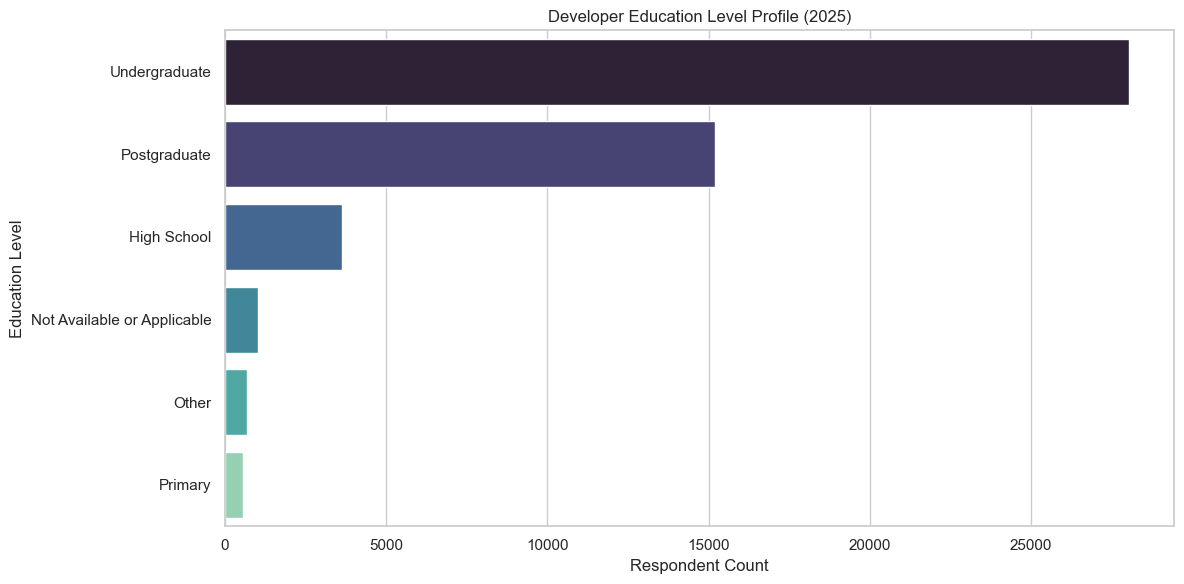

In [4]:
edu_query = """
SELECT 
    edu.Education_Level, 
    COUNT(DISTINCT f.ResponseKey) AS Count
FROM Snowflake.Fact_Survey_Core f
JOIN Snowflake.Dim_Education edu ON f.Dim_EducationID = edu.Dim_EducationID
WHERE YEAR(f.SurveyYear) = 2025 AND edu.Education_Level IS NOT NULL AND edu.Education_Level <> 'Unknown' AND edu.Education_Level <> ''
GROUP BY edu.Education_Level;
"""
df_edu = db.read_query(edu_query)

if df_edu is not None and not df_edu.empty:
    df_edu_sorted = df_edu.sort_values(by='Count', ascending=False)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_edu_sorted, x='Count', y='Education_Level', palette='mako')
    plt.title('Developer Education Level Profile (2025)')
    plt.xlabel('Respondent Count')
    plt.ylabel('Education Level')
    plt.tight_layout()
    plt.savefig(os.path.join(images_dir, '06_education_profile.png'), dpi=300)
    plt.show()
else:
    print("No education profile data available.")

In [5]:
db.close()

Connection closed.
